# Fairness Analysis

Logistic regression trained on the 130-US Hospitals Diabetes Dataset (1999–2008) to predict 30-day readmission. We assess fairness across gender, race, and insurance (payer code) groups, using False Negative Rate (FNR) as our primary fairness metric.

<br><br>

## 0. Setup

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from fairlearn.preprocessing import CorrelationRemover
from sklearn.metrics import confusion_matrix

In [154]:
# Load data
diabetes = pd.read_csv("data/diabetes_processed.csv")
ids = pd.read_csv("data/diabetes/IDS_mapping.csv")

In [155]:
target_name = 'readmitted'

X = diabetes[[c for c in diabetes if c != target_name]].copy()
y = diabetes[target_name].copy()

# Protected attribute for fairness analysis
group = diabetes["gender"].astype(int)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X,
    y,
    group,
    test_size=0.2,
    random_state=0,
    stratify=y
)

<br><br>

## 1. Baseline Model

Full logistic regression trained on all available features including sensitive attributes (race, gender, payer code). Uses `class_weight='balanced'` to compensate for the ~9:1 class imbalance.

In [156]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 55989 entries, 62192 to 5861
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   gender                                        55989 non-null  int64
 1   age                                           55989 non-null  int64
 2   time_in_hospital                              55989 non-null  int64
 3   num_lab_procedures                            55989 non-null  int64
 4   num_procedures                                55989 non-null  int64
 5   num_medications                               55989 non-null  int64
 6   number_diagnoses                              55989 non-null  int64
 7   metformin                                     55989 non-null  int64
 8   repaglinide                                   55989 non-null  int64
 9   nateglinide                                   55989 non-null  int64
 10  glimepiride            

In [157]:
def print_classification_results(y_test, y_pred):
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

In [158]:
def get_log_reg_pipeline(
    seed: int = 70766,
    max_iter: int = 5000,
    penalty: str = 'l2',
    C: float = 0.8497534359086438,
    tol: float = 1e-4,
    solver: str = 'saga'
):
    scaler = StandardScaler() # Standard scale for log reg
    model = LogisticRegression(
        class_weight='balanced',
        penalty = penalty,
        C = C,
        random_state = seed,
        max_iter = max_iter,
        tol = tol,
        solver = solver
    )
    pipeline = Pipeline([('scaler', scaler), ('classifier', model)])
    return pipeline

In [159]:
# Get pipeline and fit to training data
log_reg = get_log_reg_pipeline()
log_reg.fit(X_train, y_train)

# Predict on test set
y_pred = log_reg.predict(X_test)

# Evaluate
print_classification_results(y_test, y_pred)

/Users/sanderengelthilo/Documents/ITU/AFAE/exam/afae_exam_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.6299
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     12741
           1       0.13      0.54      0.21      1257

    accuracy                           0.63     13998
   macro avg       0.53      0.59      0.48     13998
weighted avg       0.86      0.63      0.71     13998



In [160]:
print(confusion_matrix(y_test, y_pred))

[[8134 4607]
 [ 573  684]]


<br><br>

## 2. Fairness Analysis

### 2.1 Helper Functions

In [161]:
def get_scores_test(model, X_test):
    return model.predict_proba(X_test)[:, 1]

# def make_selection(scores_test, thresholds: tuple = (.5, .5)):
#     # Apply group-specific thresholds
#     selections = np.zeros_like(scores_test)
#     selections[group_test == 0] = (scores_test[group_test == 0] >= thresholds[0]).astype(int)
#     selections[group_test == 1] = (scores_test[group_test == 1] >= thresholds[1]).astype(int)
#     return selections

# Define function to evaluate fairness
def evaluate_fairness(S, T, G):
    df = pd.DataFrame({'S': S, 'T': T, 'G': G})

    results = {}
    for g in [0, 1]: # Male, Female
        subset = df[df['G'] == g]

        # Statistical/demographic parity P(S=1|G)
        results[f'G={g}_Selection_Rate'] = subset['S'].mean()

        # Equalized Odds P(S=1|G, T)
        results[f'G={g}_TPR'] = subset[subset['T'] == 1]['S'].mean()
        results[f'G={g}_FPR'] = subset[subset['T'] == 0]['S'].mean()

        # Equalized Outcome P(T=1|G, S)
        results[f'G={g}_Prec'] = subset[subset['S'] == 1]['T'].mean()
        results[f'G={g}_NPV'] = subset[subset['S'] == 0]['T'].mean()

    return results

def print_fairness_overiew(fairness_metrics: dict, epsilon: float = 1e-3):
    # Statistical parity
    print('Statistical Parity:')
    g1_selection_rate = fairness_metrics['G=0_Selection_Rate']
    g2_selection_rate = fairness_metrics['G=1_Selection_Rate']
    print(f'Group 0 Selection Rate P(S=1|G=0): {g1_selection_rate:.4f}')
    print(f'Group 1 Selection Rate P(S=1|G=1): {g2_selection_rate:.4f}')
    if abs(g1_selection_rate - g2_selection_rate) < epsilon:
        print('Statistical parity (approximately) achieved.')
    else:
        print('Statistical parity not achieved.')
    print('')

    # Equalized Odds
    print('Equalized Odds:')
    g0_tpr = fairness_metrics['G=0_TPR']
    g1_tpr = fairness_metrics['G=1_TPR']
    g0_fpr = fairness_metrics['G=0_FPR']
    g1_fpr = fairness_metrics['G=1_FPR']

    print(f'Group 0 True Positive Rate P(S=1|G=0,T=1): {g0_tpr:.4f}')
    print(f'Group 1 True Positive Rate P(S=1|G=1,T=1): {g1_tpr:.4f}')

    print(f'Group 0 False Positive Rate P(S=1|G=0,T=0): {g0_fpr:.4f}')
    print(f'Group 1 False Positive Rate P(S=1|G=1,T=0): {g1_fpr:.4f}')
    if abs(g0_tpr - g1_tpr) < epsilon and abs(g0_fpr - g1_fpr) < epsilon:
        print('Equalized odds (approximately) achieved.')
    else:
        print('Equalized odds not achieved.')

def plot_fairness_metrics(fairness_metrics: dict, scores_test, roc_cross: tuple = None):
    _, axes = plt.subplots(1, 2, figsize = (12, 6))

    # ROC curve
    for g, label in zip([0, 1], ['Group 0', 'Group 1']):
        idx = group_test == g
        fpr, tpr, _ = roc_curve(y_test[idx], scores_test[idx])
        axes[0].plot(fpr, tpr, label=label)

    if roc_cross is not None:
        axes[0].scatter([roc_cross[0]], [roc_cross[1]], marker = 'x', color = 'red', s = 100)

    axes[0].grid(True, linestyle = '--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve by Group')
    axes[0].legend()

    # Bar plot
    groups = ['Group 0', 'Group 1']
    selection_rates = [fairness_metrics['G=0_Selection_Rate'], fairness_metrics['G=1_Selection_Rate']]
    axes[1].bar(groups, selection_rates)
    axes[1].set_ylabel('Selection Rate')
    axes[1].set_title('Selection Rate by Group')
    plt.show()

In [162]:
def evaluate_fairness_by_group(S, T, G):
    df = pd.DataFrame({"S": S, "T": T, "G": G})

    results = {}

    for g in df["G"].unique():
        subset = df[df["G"] == g]

        results[f"G={g}_Selection_Rate"] = subset["S"].mean()
        results[f"G={g}_TPR"] = subset[subset["T"] == 1]["S"].mean()
        results[f"G={g}_FPR"] = subset[subset["T"] == 0]["S"].mean()
        results[f"G={g}_Prec"] = subset[subset["S"] == 1]["T"].mean()
        results[f"G={g}_NPV"] = subset[subset["S"] == 0]["T"].mean()

    return results

In [163]:
def plot_fairness_by_group(fairness_metrics, scores_test, group_values, title="Group"):
    _, axes = plt.subplots(1, 2, figsize=(14, 6))

    for g in group_values.unique():
        idx = group_values == g

        # Only plot ROC if the group has both classes
        if y_test[idx].nunique() == 2:
            fpr, tpr, _ = roc_curve(y_test[idx], scores_test[idx])
            axes[0].plot(fpr, tpr, label=str(g))

    axes[0].grid(True, linestyle="--")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve by {title}")
    axes[0].legend()

    groups = list(group_values.unique())
    selection_rates = [
        fairness_metrics[f"G={g}_Selection_Rate"]
        for g in groups
    ]

    axes[1].bar(groups, selection_rates)
    axes[1].set_ylabel("Selection Rate")
    axes[1].set_title(f"Selection Rate by {title}")
    axes[1].tick_params(axis="x", rotation=45)

    plt.show()

### 2.2 Fairness by Gender

Statistical Parity:
Group 0 Selection Rate P(S=1|G=0): 0.3814
Group 1 Selection Rate P(S=1|G=1): 0.3741
Statistical parity not achieved.

Equalized Odds:
Group 0 True Positive Rate P(S=1|G=0,T=1): 0.5253
Group 1 True Positive Rate P(S=1|G=1,T=1): 0.5658
Group 0 False Positive Rate P(S=1|G=0,T=0): 0.3672
Group 1 False Positive Rate P(S=1|G=1,T=0): 0.3553
Equalized odds not achieved.


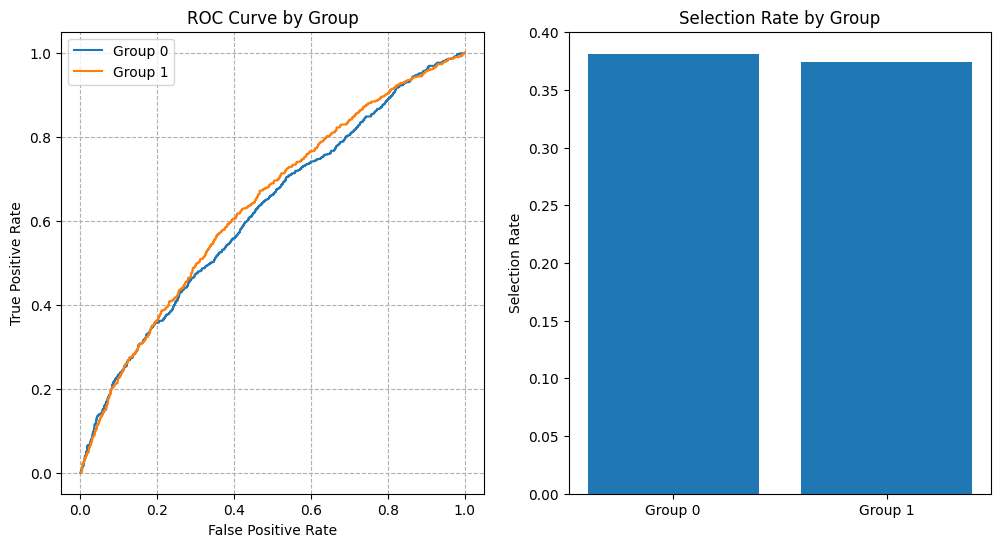

In [164]:
# Get test scores and make selections
log_reg_scores = get_scores_test(log_reg, X_test)
log_reg_fairness_metrics = evaluate_fairness(y_pred, y_test, group_test)
print_fairness_overiew(log_reg_fairness_metrics)
plot_fairness_metrics(log_reg_fairness_metrics, log_reg_scores)

### 2.3 Fairness by Race

In [165]:
def get_race(row):
    if row["race_AfricanAmerican"] == 1:
        return "AfricanAmerican"
    elif row["race_Asian"] == 1:
        return "Asian"
    elif row["race_Hispanic"] == 1:
        return "Hispanic"
    elif row["race_Other"] == 1:
        return "Other"
    elif row["race_Unknown"] == 1:
        return "Unknown"
    else:
        return "Caucasian"

race_test = X_test.apply(get_race, axis=1)
print(race_test.value_counts())

Caucasian          10954
AfricanAmerican     2450
Hispanic             279
Other                232
Asian                 83
Name: count, dtype: int64


In [166]:
# Compute race fairness metrics
race_fairness_metrics = evaluate_fairness_by_group(y_pred, y_test, race_test)

In [167]:
race_results = []

for race in race_test.unique():
    tpr = race_fairness_metrics[f"G={race}_TPR"]
    race_results.append({
        "Race": race,
        "N": int((race_test == race).sum()),
        "Base Rate": round(y_test[race_test == race].mean(), 4),
        "Selection Rate": round(race_fairness_metrics[f"G={race}_Selection_Rate"], 4),
        "TPR": round(tpr, 4),
        "FNR": round(1 - tpr, 4),
        "FPR": round(race_fairness_metrics[f"G={race}_FPR"], 4),
    })

race_fairness_df = pd.DataFrame(race_results).sort_values("N", ascending=False)
race_fairness_df

,Race,N,Base Rate,Selection Rate,TPR,FNR,FPR
0,Caucasian,10954,0.0922,0.3915,0.5535,0.4465,0.3751
1,AfricanAmerican,2450,0.0849,0.3412,0.5192,0.4808,0.3247
2,Hispanic,279,0.0609,0.3082,0.4706,0.5294,0.2977
3,Other,232,0.0690,0.2457,0.3125,0.6875,0.2407
4,Asian,83,0.0723,0.2771,0.6667,0.3333,0.2468


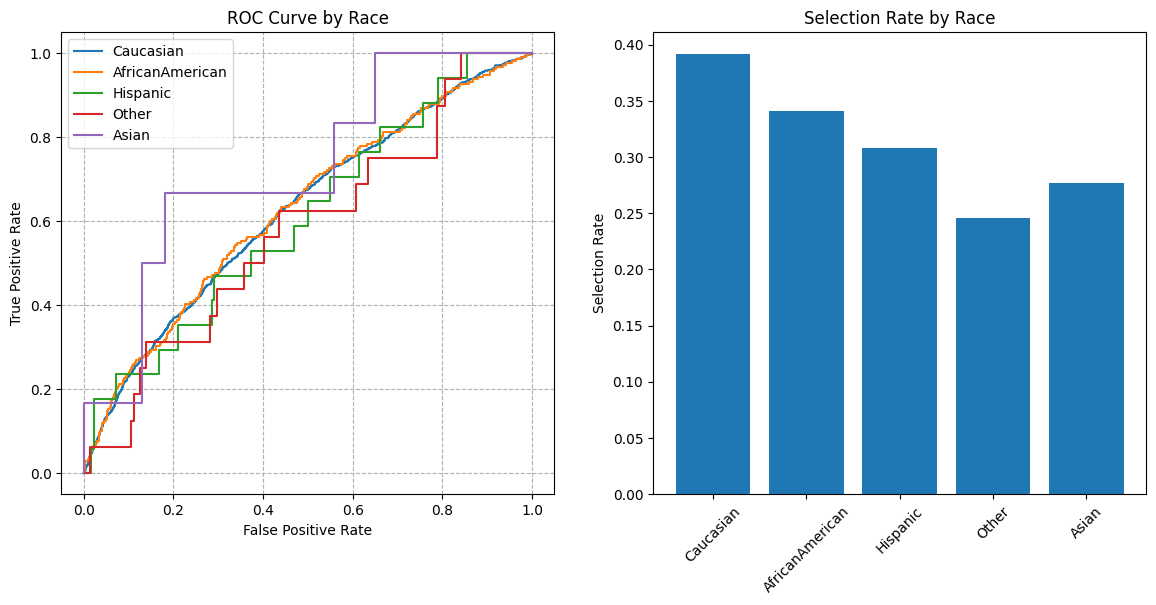

In [168]:
plot_fairness_by_group(
    race_fairness_metrics,
    log_reg_scores,
    race_test,
    title="Race"
)

### 2.4 Fairness by Payer Code (Social Proxy)

Payer code (insurance type) may act as a social proxy for race and socioeconomic status. We test whether the model shows disparate error rates across insurance groups.

In [169]:
# Reconstruct payer code group from one-hot encoded payer columns
payer_columns = [col for col in X_test.columns if col.startswith("payer_code_")]

def get_payer(row):
    for col in payer_columns:
        if row[col] == 1:
            return col.replace("payer_code_", "")
    return "Unknown"

payer_test = X_test.apply(get_payer, axis=1)

In [170]:
# Fairness evaluation function for multiple groups
def evaluate_fairness_by_group(S, T, G):
    df = pd.DataFrame({"S": S, "T": T, "G": G})

    results = {}

    for g in df["G"].unique():
        subset = df[df["G"] == g]

        results[f"G={g}_Selection_Rate"] = subset["S"].mean()
        results[f"G={g}_TPR"] = subset[subset["T"] == 1]["S"].mean()
        results[f"G={g}_FPR"] = subset[subset["T"] == 0]["S"].mean()
        results[f"G={g}_Prec"] = subset[subset["S"] == 1]["T"].mean()
        results[f"G={g}_NPV"] = subset[subset["S"] == 0]["T"].mean()

    return results

In [171]:
# Compute fairness metrics
payer_fairness_metrics = evaluate_fairness_by_group(
    y_pred,
    y_test,
    payer_test
)

payer_fairness_metrics

{'G=MC_Selection_Rate': np.float64(0.4604334063793523),
 'G=MC_TPR': np.float64(0.6015831134564644),
 'G=MC_FPR': np.float64(0.44608369098712447),
 'G=MC_Prec': np.float64(0.12057112638815441),
 'G=MC_NPV': np.float64(0.06814079422382671),
 'G=PO_Selection_Rate': np.float64(0.06172839506172839),
 'G=PO_TPR': np.float64(0.2),
 'G=PO_FPR': np.float64(0.05263157894736842),
 'G=PO_Prec': np.float64(0.2),
 'G=PO_NPV': np.float64(0.05263157894736842),
 'G=Unknown_Selection_Rate': np.float64(0.4),
 'G=Unknown_TPR': np.float64(0.5735056542810986),
 'G=Unknown_FPR': np.float64(0.38184584178498987),
 'G=Unknown_Prec': np.float64(0.13580719204284622),
 'G=Unknown_NPV': np.float64(0.06732976281560826),
 'G=MD_Selection_Rate': np.float64(0.2835820895522388),
 'G=MD_TPR': np.float64(0.3684210526315789),
 'G=MD_FPR': np.float64(0.27610208816705334),
 'G=MD_Prec': np.float64(0.10526315789473684),
 'G=MD_NPV': np.float64(0.07142857142857142),
 'G=SP_Selection_Rate': np.float64(0.24087591240875914),
 'G

In [172]:
# Create fairness results table
payer_results = []

for payer in payer_test.unique():
    payer_results.append({
        "Payer Code": payer,
        "N": (payer_test == payer).sum(),
        "Selection Rate": payer_fairness_metrics[f"G={payer}_Selection_Rate"],
        "TPR": payer_fairness_metrics[f"G={payer}_TPR"],
        "FPR": payer_fairness_metrics[f"G={payer}_FPR"],
        "Precision": payer_fairness_metrics[f"G={payer}_Prec"],
        "NPV": payer_fairness_metrics[f"G={payer}_NPV"]
    })

payer_fairness_df = pd.DataFrame(payer_results)

payer_fairness_df.sort_values("N", ascending=False)

,Payer Code,N,Selection Rate,TPR,FPR,Precision,NPV
2,Unknown,6535,0.400000,0.573506,0.381846,0.135807,0.067330
0,MC,4107,0.460433,0.601583,0.446084,0.120571,0.068141
5,HM,823,0.195626,0.344262,0.183727,0.130435,0.060423
4,SP,685,0.240876,0.433962,0.224684,0.139394,0.057692
3,MD,469,0.283582,0.368421,0.276102,0.105263,0.071429
8,CP,384,0.151042,0.259259,0.142857,0.120690,0.061350
10,UN,378,0.264550,0.500000,0.245714,0.140000,0.050360
7,CM,250,0.360000,0.631579,0.337662,0.133333,0.043750
9,OG,156,0.160256,0.133333,0.163121,0.080000,0.099237
1,PO,81,0.061728,0.200000,0.052632,0.200000,0.052632


In [173]:
# Plot fairness metrics by payer group
def plot_fairness_by_group(
    fairness_metrics,
    scores_test,
    group_values,
    y_true,
    title="Group"
):
    _, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC curves
    for g in group_values.unique():
        idx = group_values == g

        if y_true[idx].nunique() == 2:
            fpr, tpr, _ = roc_curve(y_true[idx], scores_test[idx])
            axes[0].plot(fpr, tpr, label=str(g))

    axes[0].grid(True, linestyle="--")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve by {title}")
    axes[0].legend()

    # Selection rates
    groups = list(group_values.unique())

    selection_rates = [
        fairness_metrics[f"G={g}_Selection_Rate"]
        for g in groups
    ]

    axes[1].bar(groups, selection_rates)

    axes[1].set_ylabel("Selection Rate")
    axes[1].set_title(f"Selection Rate by {title}")
    axes[1].tick_params(axis="x", rotation=45)

    plt.show()

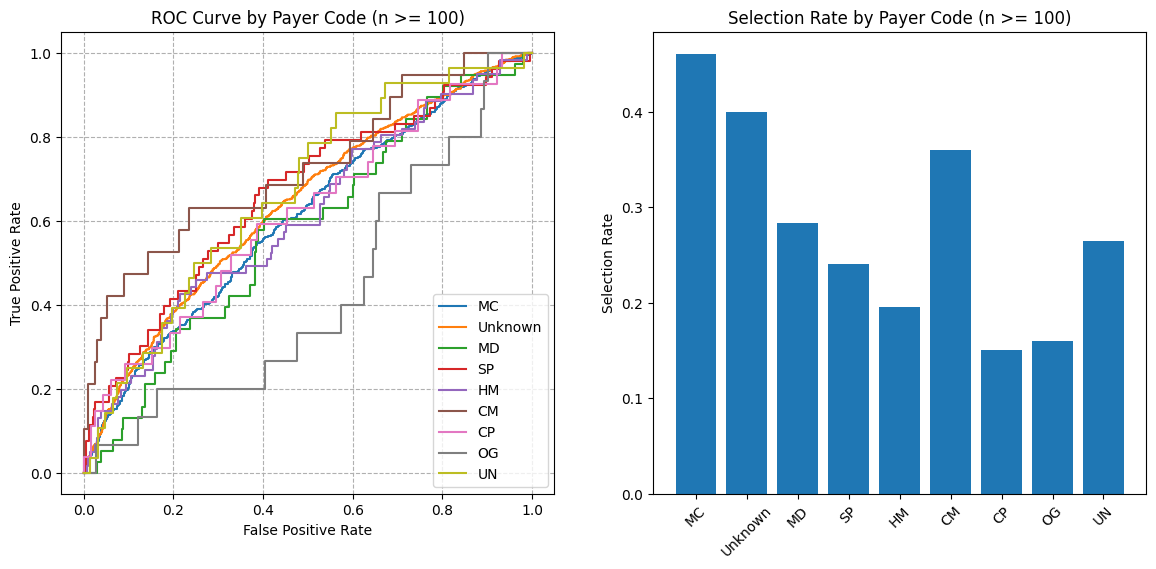

In [174]:
# Filter to not plot small payer groups
min_n = 100

payer_counts = payer_test.value_counts()
valid_payers = payer_counts[payer_counts >= min_n].index

mask = payer_test.isin(valid_payers).values

# Plot payer-code fairness
plot_fairness_by_group(
    payer_fairness_metrics,
    log_reg_scores[mask],
    payer_test[mask],
    y_test.iloc[mask],
    title=f"Payer Code (n >= {min_n})"
)

<br><br>

## 3. Explainability — SHAP

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions. We examine both global patterns and the specific role of sensitive demographic features.

### 3.1 Global Explanations

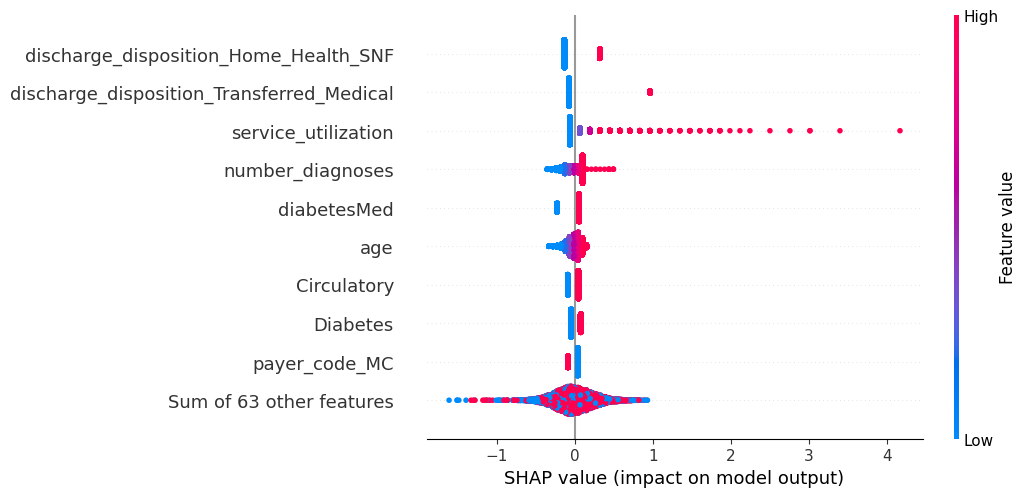

In [175]:
scaler = log_reg.named_steps["scaler"]
clf_lr = log_reg.named_steps["classifier"]

# Scaleing train and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


explainer = shap.Explainer(clf_lr, X_train_scaled_df)
shap_values = explainer(X_test_scaled_df)
shap.plots.beeswarm(shap_values, max_display=10)

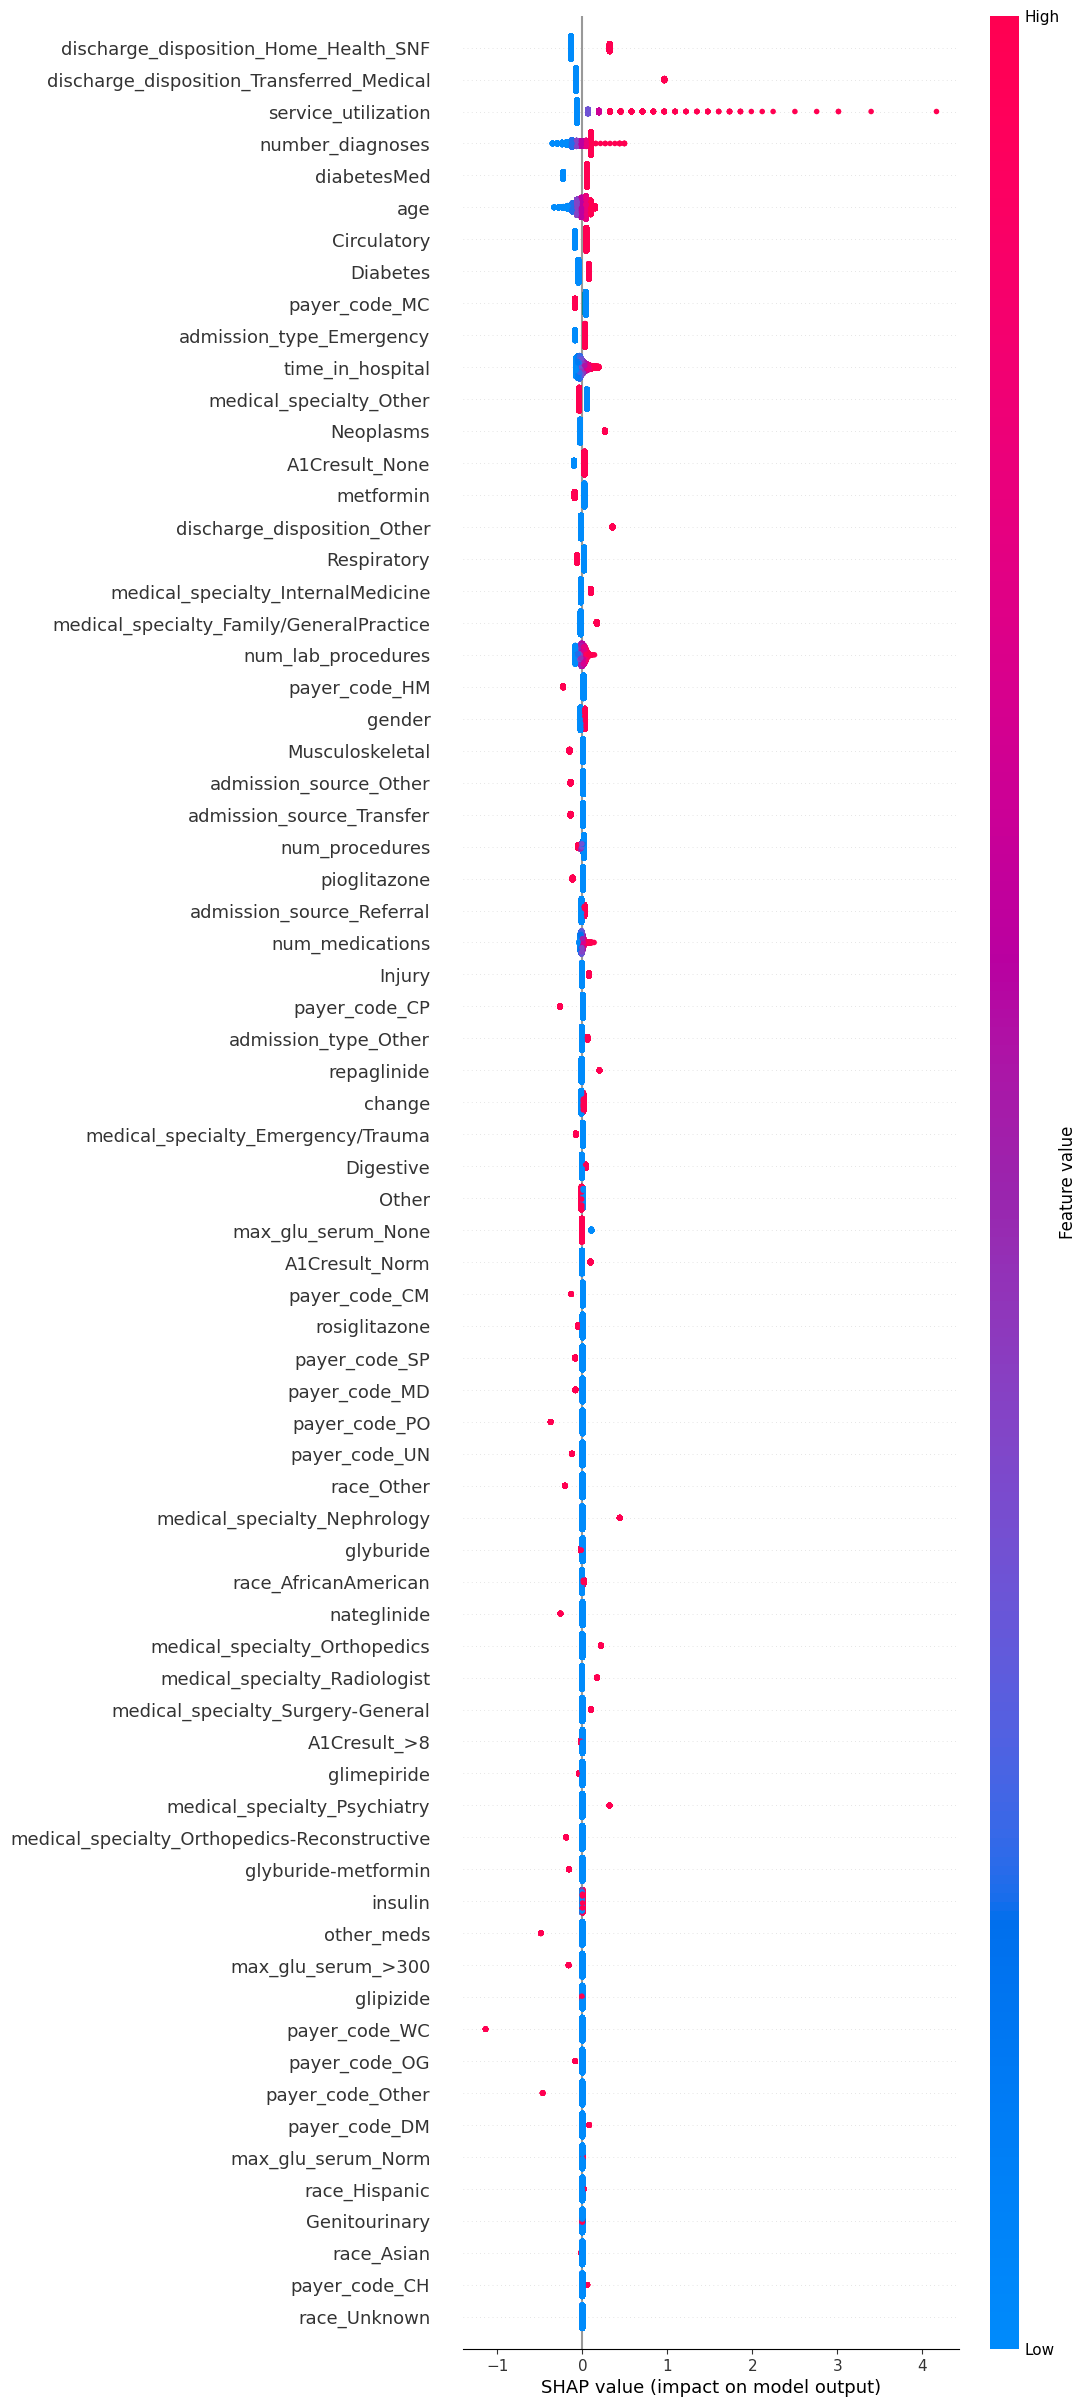

In [176]:
shap.plots.beeswarm(shap_values, max_display=len(X_train.columns))

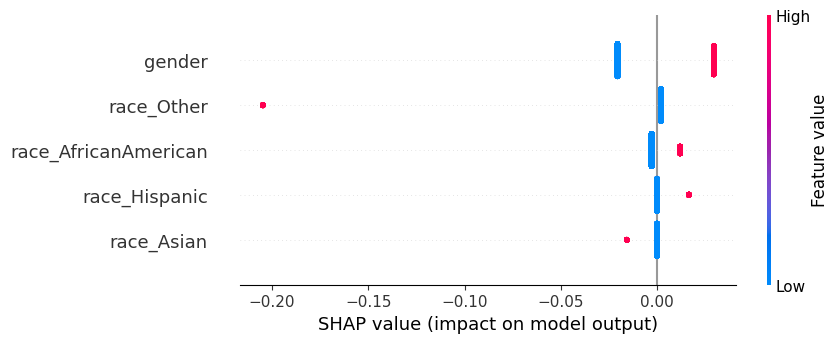

In [177]:
sensitive_features = [
    "gender",
    "race_Asian",
    "race_AfricanAmerican",
    "race_Hispanic",
    "race_Other"
]

# Get column indices of sensitive features
sensitive_idx = [
    list(X_train.columns).index(col)
    for col in sensitive_features
]

# Creating SHAP values for only sensitive features
sensitive_shap = shap_values[:, sensitive_idx]
shap.plots.beeswarm(sensitive_shap)

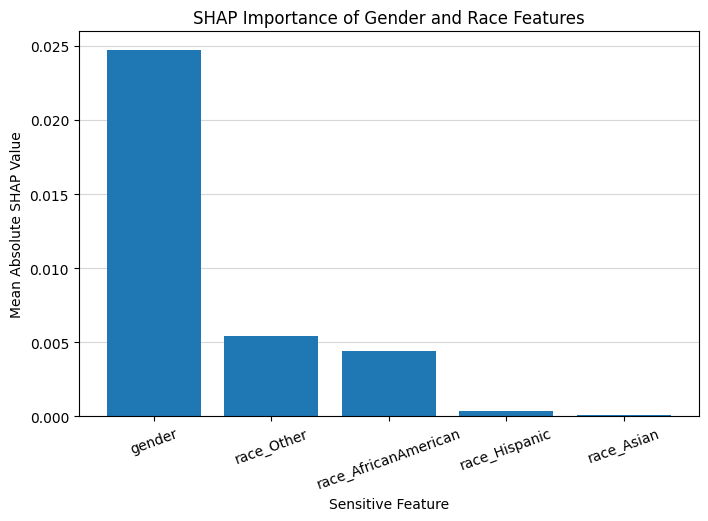

In [178]:
sensitive_features = [
    "gender",
    "race_Asian",
    "race_AfricanAmerican",
    "race_Hispanic",
    "race_Other"
]

# Computing mean absolute SHAP values
mean_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": mean_shap
})

# Keeping only sensitive features
protected_importance = importance_df[
    importance_df["feature"].isin(sensitive_features)
].sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(
    protected_importance["feature"],
    protected_importance["mean_abs_shap"],
    zorder=2
)
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Sensitive Feature")
plt.title("SHAP Importance of Gender and Race Features")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.5, zorder=1)
plt.show()

### 3.2 Local Explanations

Bar plots showing feature contributions for a single patient prediction.

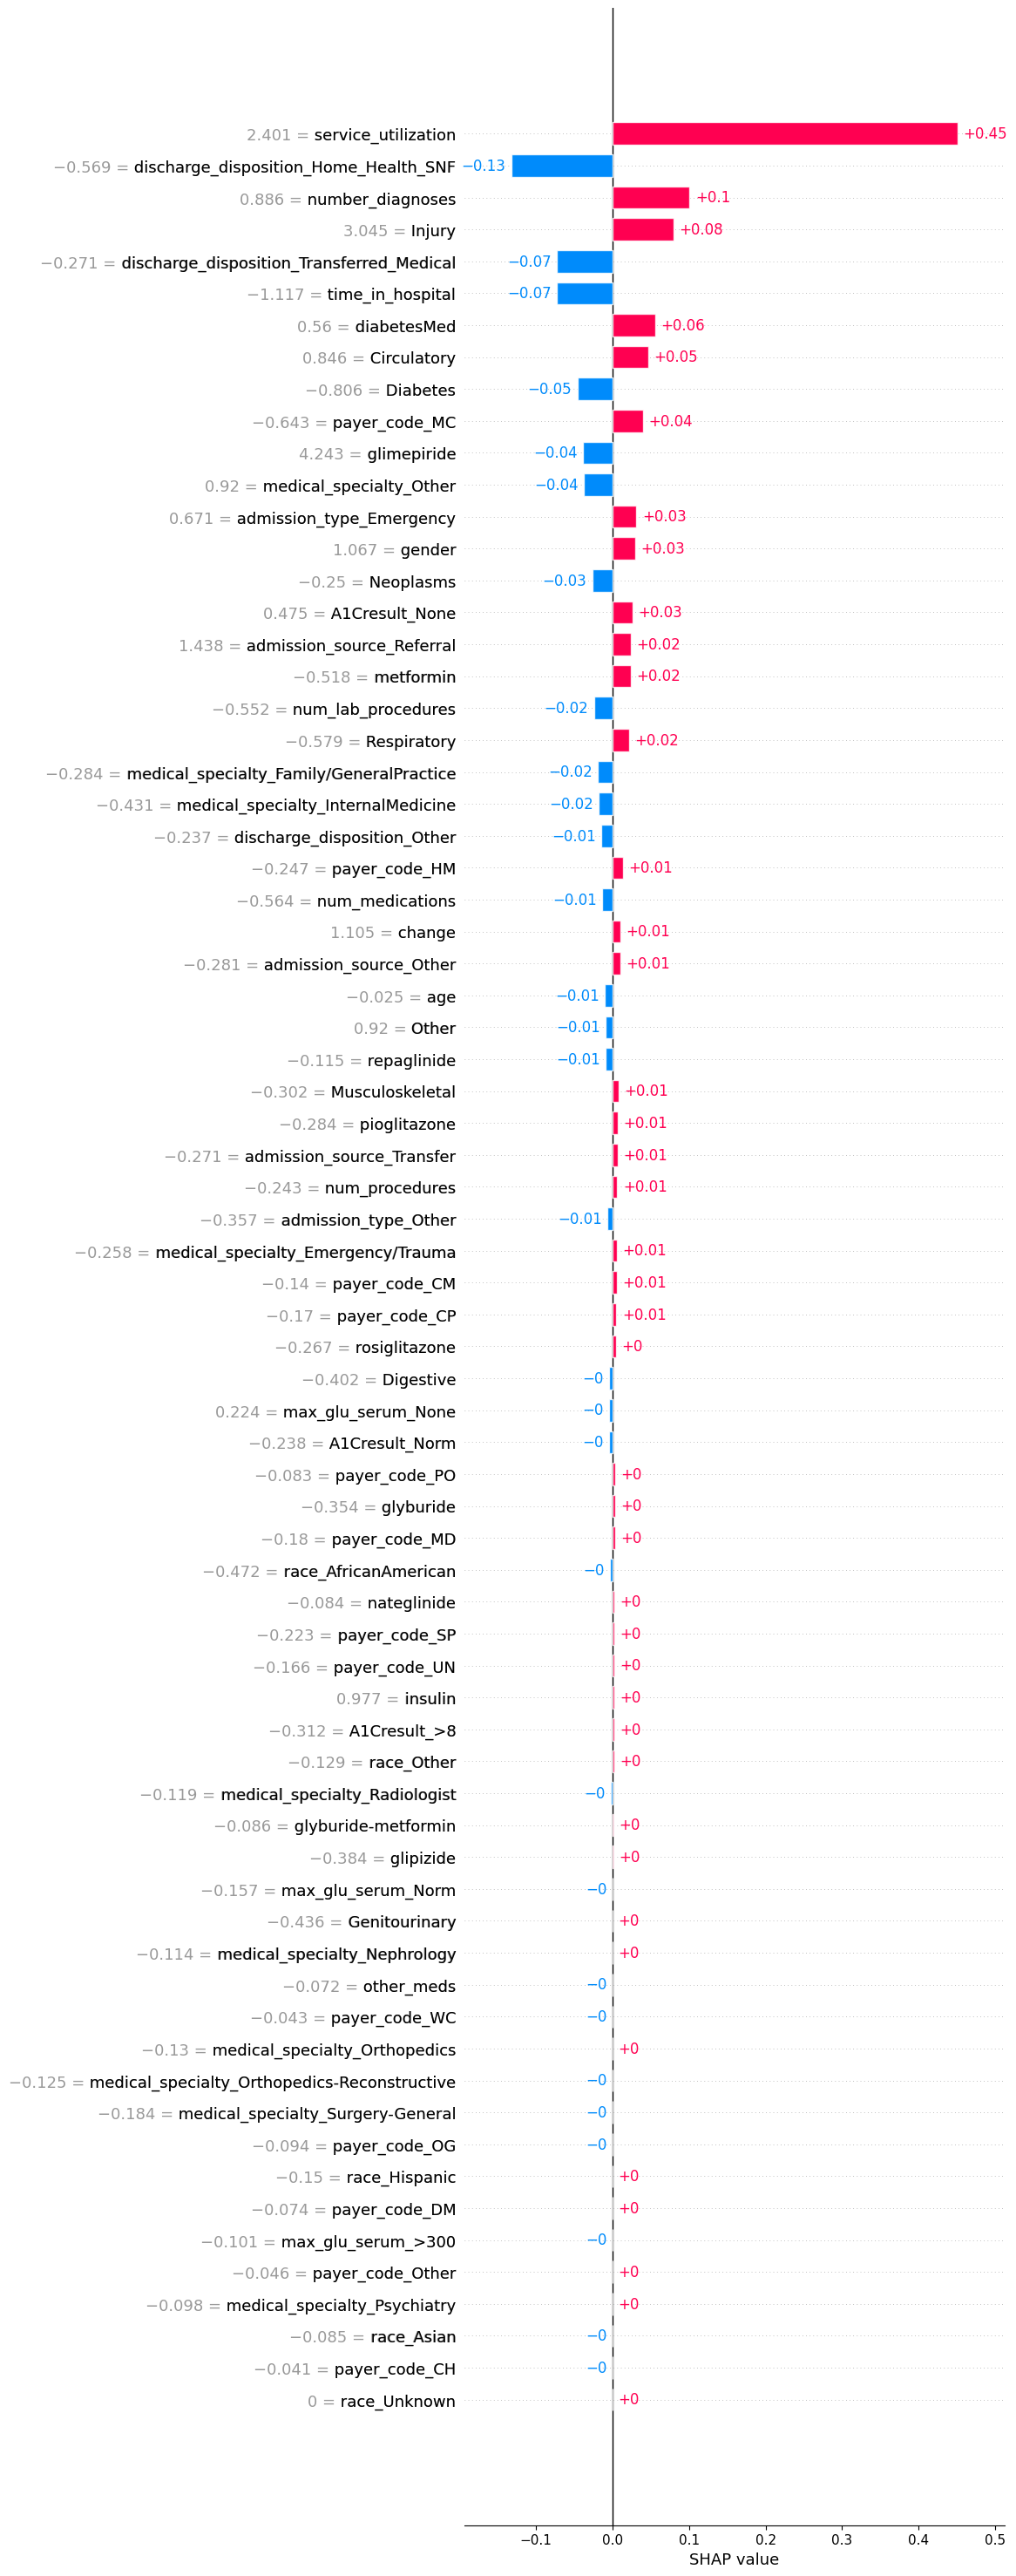

In [179]:
feature_names = X_train.columns
explainer_lr = shap.LinearExplainer(clf_lr, X_train_scaled,feature_names=feature_names)
shap_values_lr = explainer_lr(X_test_scaled)

shap.plots.bar(shap_values_lr[20],max_display=len(X_train.columns))

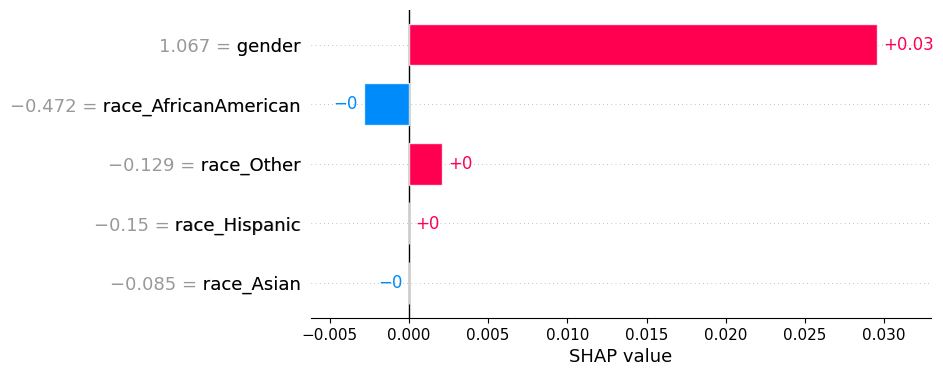

In [180]:
sensitive_shap_values = shap_values_lr[:, sensitive_idx]
shap.plots.bar(
    sensitive_shap_values[20],
    max_display=len(sensitive_features)
)

In [181]:
X_test.iloc[20][[
    "race_Asian",
    "race_AfricanAmerican",
    "race_Hispanic",
    "race_Other"
]]

race_Asian              0
race_AfricanAmerican    0
race_Hispanic           0
race_Other              0
Name: 40809, dtype: int64

<br><br>

## 4. Unaware Model

We retrain the same logistic regression after dropping all sensitive attributes: `gender`, all `race_*` columns, and all `payer_code_*` columns (insurance). This tests whether removing explicit proxies reduces disparity, or whether the model finds the signal through correlated clinical features anyway.

### 4.1. Define Features and Split

In [182]:
# Drop sensitive columns
race_columns = [c for c in X.columns if c.startswith('race_')]
sensitive_cols = (['gender'] + race_columns + payer_columns)

X_train_unaware = X_train.drop(columns = sensitive_cols).copy()
X_test_unaware = X_test.drop(columns = sensitive_cols).copy()

### 4.2. Fit Logistic Regression

In [183]:
# Fit
log_reg_unaware = get_log_reg_pipeline()
log_reg_unaware.fit(X_train_unaware, y_train)

# Predict
y_pred_unaware = log_reg_unaware.predict(X_test_unaware)
print_classification_results(y_test, y_pred_unaware)

/Users/sanderengelthilo/Documents/ITU/AFAE/exam/afae_exam_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.6314
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     12741
           1       0.13      0.53      0.21      1257

    accuracy                           0.63     13998
   macro avg       0.53      0.59      0.48     13998
weighted avg       0.86      0.63      0.71     13998



In [184]:
unaware_scores = get_scores_test(log_reg_unaware, X_test_unaware)

### 4.3. Race Fairness

In [185]:
unaware_race_metrics = evaluate_fairness_by_group(y_pred_unaware, y_test, race_test)

unaware_race_results = []
for race in race_test.unique():
    tpr = unaware_race_metrics[f'G={race}_TPR']
    unaware_race_results.append({
        'Race': race,
        'N': int((race_test == race).sum()),
        'Selection Rate': round(unaware_race_metrics[f'G={race}_Selection_Rate'], 4),
        'TPR': round(tpr, 4),
        'FNR': round(1 - tpr, 4),
        'FPR': round(unaware_race_metrics[f'G={race}_FPR'], 4),
    })

pd.DataFrame(unaware_race_results).sort_values('N', ascending = False)

,Race,N,Selection Rate,TPR,FNR,FPR
0,Caucasian,10954,0.3881,0.5465,0.4535,0.3720
1,AfricanAmerican,2450,0.3278,0.4712,0.5288,0.3145
2,Hispanic,279,0.2867,0.3529,0.6471,0.2824
3,Other,232,0.3405,0.4375,0.5625,0.3333
4,Asian,83,0.2771,0.6667,0.3333,0.2468


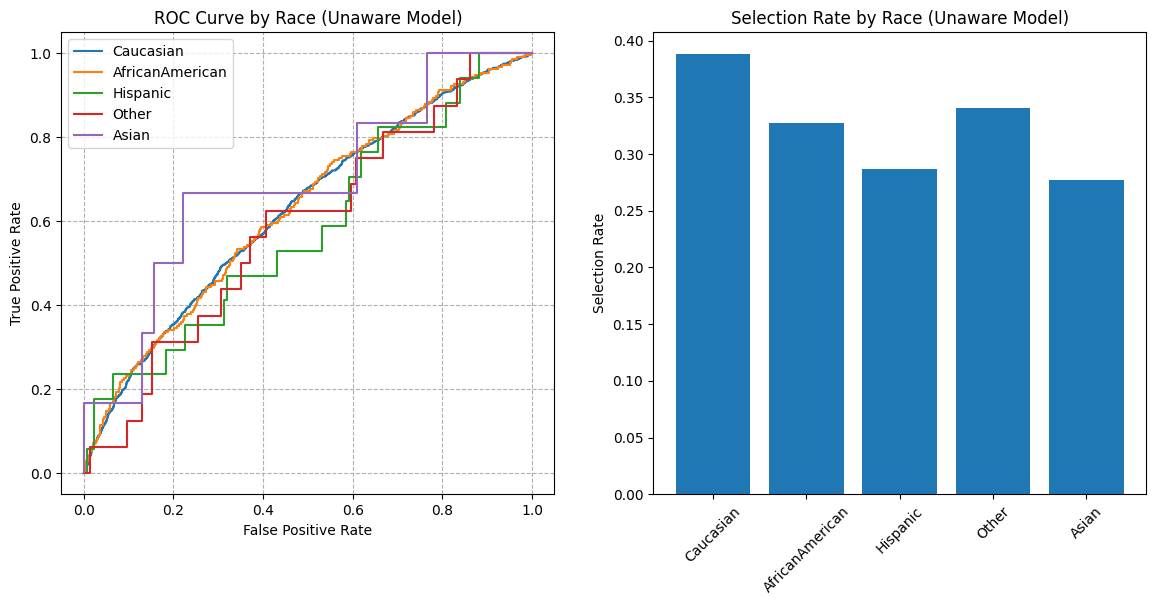

In [186]:
plot_fairness_by_group(
    unaware_race_metrics,
    unaware_scores,
    race_test,
    y_test,
    title="Race (Unaware Model)"
)

In [187]:
# Side-by-side FNR comparison
full_fnr = {r: round(1 - race_fairness_metrics[f'G={r}_TPR'], 4) for r in race_test.unique()}
unaware_fnr = {r: round(1 - unaware_race_metrics[f'G={r}_TPR'], 4) for r in race_test.unique()}

unaware_race_comparison = pd.DataFrame({
    'Race': list(full_fnr.keys()),
    'N': [(race_test == r).sum() for r in full_fnr],
    'FNR (Full)': list(full_fnr.values()),
    'FNR (Unaware)': list(unaware_fnr.values()),
}).sort_values('N', ascending = False)

unaware_race_comparison['Delta FNR'] = (unaware_race_comparison['FNR (Unaware)'] - unaware_race_comparison['FNR (Full)']).round(4)
unaware_race_comparison

,Race,N,FNR (Full),FNR (Unaware),Delta FNR
0,Caucasian,10954,0.4465,0.4535,0.0070
1,AfricanAmerican,2450,0.4808,0.5288,0.0480
2,Hispanic,279,0.5294,0.6471,0.1177
3,Other,232,0.6875,0.5625,-0.1250
4,Asian,83,0.3333,0.3333,0.0000


### 4.4. Payer Code Fairness

In [188]:
unaware_payer_metrics = evaluate_fairness_by_group(
    y_pred_unaware,
    y_test,
    payer_test
)

unaware_payer_results = []
for payer in payer_test.unique():
    tpr = unaware_payer_metrics[f'G={payer}_TPR']
    unaware_payer_results.append({
        'Payer': payer,
        'N': int((payer_test == payer).sum()),
        'FNR (Full)':    round(1 - payer_fairness_metrics[f'G={payer}_TPR'], 4),
        'FNR (Unaware)': round(1 - tpr, 4),
    })

unaware_payer_comparison = pd.DataFrame(unaware_payer_results).sort_values('N', ascending = False)
unaware_payer_comparison['Delta FNR'] = (unaware_payer_comparison['FNR (Unaware)'] - unaware_payer_comparison['FNR (Full)']).round(4)
unaware_payer_comparison

,Payer,N,FNR (Full),FNR (Unaware),Delta FNR
2,Unknown,6535,0.4265,0.4782,0.0517
0,MC,4107,0.3984,0.3799,-0.0185
5,HM,823,0.6557,0.5410,-0.1147
4,SP,685,0.5660,0.5849,0.0189
3,MD,469,0.6316,0.6316,0.0000
8,CP,384,0.7407,0.6667,-0.0740
10,UN,378,0.5000,0.5000,0.0000
7,CM,250,0.3684,0.3684,0.0000
9,OG,156,0.8667,0.8667,0.0000
1,PO,81,0.8000,0.8000,0.0000


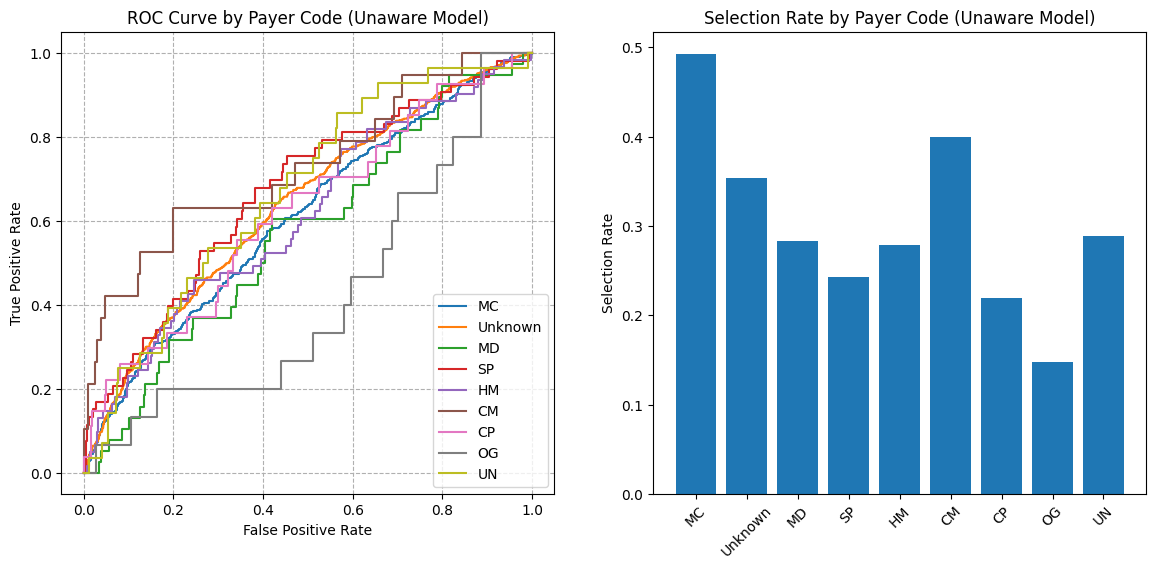

In [189]:
# Filter to not plot small payer groups
min_n = 100

payer_counts = payer_test.value_counts()
valid_payers = payer_counts[payer_counts >= min_n].index

mask = payer_test.isin(valid_payers).values

plot_fairness_by_group(
    unaware_payer_metrics,
    unaware_scores[mask],
    payer_test[mask],
    y_test.iloc[mask],
    title="Payer Code (Unaware Model)"
)

<br><br>

## 5. Fairness-Aware Model (FairPCA)

FairPCA pre-processes features by projecting out their linear correlation with the
sensitive attribute (race) before training. Unlike the unaware model, which simply
drops race columns, FairPCA transforms every remaining feature to be orthogonal to
the racial subspace. The model can no longer exploit any linear proxy for race,
regardless of which feature carries it.

### 5.1. Transform

In [190]:
# Project features onto the subspace orthogonal to race
cr = CorrelationRemover(sensitive_feature_ids = race_columns)
X_train_fair_arr = cr.fit_transform(X_train)
X_test_fair_arr = cr.transform(X_test)

# Output doesn't include sensitive columns, so we reconstruct
fair_cols = [c for c in X_train.columns if c not in race_columns]
X_train_fair = pd.DataFrame(X_train_fair_arr, columns = fair_cols, index = X_train.index)
X_test_fair = pd.DataFrame(X_test_fair_arr, columns = fair_cols, index = X_test.index)

### 5.2. Fit Logisitc Regression

In [191]:
log_reg_fair = get_log_reg_pipeline()
log_reg_fair.fit(X_train_fair, y_train)

y_pred_fair = log_reg_fair.predict(X_test_fair)
print_classification_results(y_test, y_pred_fair)
print(confusion_matrix(y_test, y_pred_fair))

/Users/sanderengelthilo/Documents/ITU/AFAE/exam/afae_exam_project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.6302
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     12741
           1       0.13      0.54      0.21      1257

    accuracy                           0.63     13998
   macro avg       0.53      0.59      0.48     13998
weighted avg       0.86      0.63      0.71     13998

[[8143 4598]
 [ 578  679]]


In [192]:
fair_scores = get_scores_test(log_reg_fair, X_test_fair)

### 5.2. Race Fairness

In [193]:
fair_race_metrics = evaluate_fairness_by_group(y_pred_fair, y_test, race_test)

fair_race_results = []
for race in race_test.unique():
    fair_race_results.append({
        'Race': race,
        'N': int((race_test == race).sum()),
        'FNR (Full)': round(1 - race_fairness_metrics[f'G={race}_TPR'], 4),
        'FNR (Unaware)': round(1 - unaware_race_metrics[f'G={race}_TPR'], 4),
        'FNR (FairPCA)': round(1 - fair_race_metrics[f'G={race}_TPR'], 4),
    })

fair_race_comparison = pd.DataFrame(fair_race_results).sort_values('N', ascending = False)

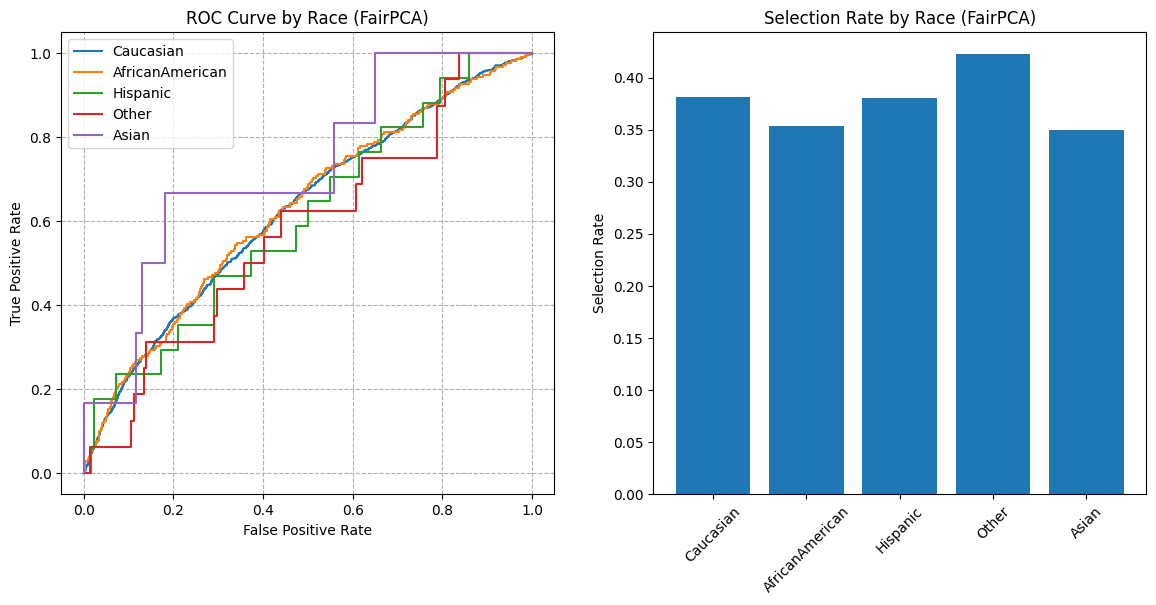

In [194]:
plot_fairness_by_group(
    fair_race_metrics,
    fair_scores,
    race_test,
    y_test,
    title="Race (FairPCA)"
)

## 5.3 Payer Code Fairness

In [195]:
fair_payer_metrics = evaluate_fairness_by_group(y_pred_fair, y_test, payer_test)

fair_payer_results = []
for payer in payer_test.unique():
    tpr_full   = payer_fairness_metrics[f'G={payer}_TPR']
    tpr_unaware = unaware_payer_metrics[f'G={payer}_TPR']
    tpr_fair   = fair_payer_metrics[f'G={payer}_TPR']
    fair_payer_results.append({
        'Payer': payer,
        'N': int((payer_test == payer).sum()),
        'FNR (Full)':    round(1 - tpr_full, 4),
        'FNR (Unaware)': round(1 - tpr_unaware, 4),
        'FNR (FairPCA)': round(1 - tpr_fair, 4),
    })

fair_payer_comparison = pd.DataFrame(fair_payer_results).sort_values('N', ascending=False)
fair_payer_comparison['Δ Full→FairPCA'] = (
    fair_payer_comparison['FNR (FairPCA)'] - fair_payer_comparison['FNR (Full)']
).round(4)
fair_payer_comparison

,Payer,N,FNR (Full),FNR (Unaware),FNR (FairPCA),Δ Full→FairPCA
2,Unknown,6535,0.4265,0.4782,0.4297,0.0032
0,MC,4107,0.3984,0.3799,0.4037,0.0053
5,HM,823,0.6557,0.5410,0.6557,0.0000
4,SP,685,0.5660,0.5849,0.5660,0.0000
3,MD,469,0.6316,0.6316,0.6316,0.0000
8,CP,384,0.7407,0.6667,0.7407,0.0000
10,UN,378,0.5000,0.5000,0.5357,0.0357
7,CM,250,0.3684,0.3684,0.3684,0.0000
9,OG,156,0.8667,0.8667,0.8667,0.0000
1,PO,81,0.8000,0.8000,0.8000,0.0000


## 6. Intersectional Analysis (Race, Gender)

A model may appear fair along each sensitive axis individually while hiding disparities that only emerge at their intersection. Here we examine subgroups defined by race × gender to test whether certain combinations face compounded disadvantage.

In [201]:
gender_test = X_test['gender'].map({0: 'Male', 1: 'Female'})
intersect_test = race_test + ', ' + gender_test

intersect_metrics = evaluate_fairness_by_group(y_pred, y_test, intersect_test)

intersect_results = []
for grp in intersect_test.unique():
    tpr = intersect_metrics[f'G={grp}_TPR']
    intersect_results.append({
        'Group': grp,
        'N': int((intersect_test == grp).sum()),
        'Base Rate': round(float(y_test[intersect_test == grp].mean()), 4),
        'Selection Rate': round(intersect_metrics[f'G={grp}_Selection_Rate'], 4),
        'FNR': round(1 - tpr, 4),
        'FPR': round(intersect_metrics[f'G={grp}_FPR'], 4),
    })

intersect_df = pd.DataFrame(intersect_results).sort_values('N', ascending=False)
intersect_df

,Group,N,Base Rate,Selection Rate,FNR,FPR
2,"Caucasian, Male",5648,0.0951,0.3982,0.4637,0.3837
0,"Caucasian, Female",5306,0.0891,0.3845,0.4271,0.3660
1,"AfricanAmerican, Male",1473,0.0788,0.3388,0.4914,0.3242
3,"AfricanAmerican, Female",977,0.0942,0.3449,0.4674,0.3254
4,"Hispanic, Male",156,0.0705,0.3141,0.5455,0.3034
8,"Other, Male",125,0.0640,0.2320,0.8750,0.2393
6,"Hispanic, Female",123,0.0488,0.3008,0.5000,0.2906
5,"Other, Female",107,0.0748,0.2617,0.5000,0.2424
7,"Asian, Female",42,0.1429,0.2381,0.3333,0.1667
9,"Asian, Male",41,0.0000,0.3171,NaN,0.3171


In [202]:
unaware_intersect_metrics = evaluate_fairness_by_group(y_pred_unaware, y_test, intersect_test)
fair_intersect_metrics    = evaluate_fairness_by_group(y_pred_fair,    y_test, intersect_test)

intersect_comparison = []
for grp in intersect_test.unique():
    n = int((intersect_test == grp).sum())
    if n < 30:
        continue
    intersect_comparison.append({
        'Group': grp,
        'N': n,
        'FNR (Full)':    round(1 - intersect_metrics[f'G={grp}_TPR'], 4),
        'FNR (Unaware)': round(1 - unaware_intersect_metrics[f'G={grp}_TPR'], 4),
        'FNR (FairPCA)': round(1 - fair_intersect_metrics[f'G={grp}_TPR'], 4),
    })

intersect_comparison_df = pd.DataFrame(intersect_comparison).sort_values('FNR (Full)', ascending=False)
intersect_comparison_df

,Group,N,FNR (Full),FNR (Unaware),FNR (FairPCA)
8,"Other, Male",125,0.8750,0.8750,0.6250
4,"Hispanic, Male",156,0.5455,0.5455,0.5455
5,"Other, Female",107,0.5000,0.2500,0.2500
6,"Hispanic, Female",123,0.5000,0.8333,0.5000
1,"AfricanAmerican, Male",1473,0.4914,0.5086,0.4741
3,"AfricanAmerican, Female",977,0.4674,0.5543,0.4565
2,"Caucasian, Male",5648,0.4637,0.4525,0.4711
0,"Caucasian, Female",5306,0.4271,0.4545,0.4440
7,"Asian, Female",42,0.3333,0.3333,0.3333
9,"Asian, Male",41,NaN,NaN,NaN
